## Mini-Projeto Avaliativo - Módulo 1 - Semana 07

Projeto desenvolvido para o mini-projeto do curso Análise de Dados - SCTEC.

**Aluna:** Laís Kugik Varela Alegri - Turma 05

**Objetivo:**  
Realizar uma Análise Exploratória de Dados (AED) aplicada ao varejo para aprender como transformar dados brutos em informações úteis.

### 1. Importando as bibliotecas

In [205]:
# Caso não tenha as bibliotecas instaladas execute essa célula antes da próxima!

%pip install -q pandas numpy seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [206]:
# Importação das bibliotecas que serão utilizadas durante o miniprojeto:

import os
import csv
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

### 2. Carregamento do dataset (base de dados)

In [144]:
# Diferente do VS Code local, o Google Colab não enxerga os arquivos desta pasta automaticamente.
# Rode essa célula para enviar o arquivo que será a nossa base de dados.
# Se estiver rodando no Google Colab, esta célula abre a janela de upload
# e organiza o arquivo na subpasta dataset/, igual à estrutura do repositório.

# Selecione o arquivo do mini projeto: Base Varejo.csv

try:
    from google.colab import files
    enviados = files.upload()
    os.makedirs("dataset", exist_ok=True)
    for nome in enviados:
        os.replace(nome, f"dataset/{nome}")
except ImportError:
    print("Rodando localmente (VS Code) — o arquivo já está em dataset/, na pasta deste projeto.")

Rodando localmente (VS Code) — o arquivo já está em dataset/, na pasta deste projeto.


### 3. Carregar a Base Varejo.csv com pandas e mostrar: número de registros, colunas e tipos de dados.


In [145]:
# Carregando o arquivo varejo.csv como um DataFrame com o Pandas

vendas = pd.read_csv("dataset/Base Varejo.csv", sep=';')

# Shape exibe a quantidade de linhas e colunas
print(f"A 'Base Varejo.csv' possui {vendas.shape[0]} registros (linhas) e {vendas.shape[1]} colunas.\n")

print(f"As colunas existentes e o tipo de dados de cada uma delas pode ser verificado abaixo:")

# Dtypes exibe o nome das colunas e o tipo
display(vendas.dtypes.reset_index(name="Tipo").rename(columns={"index": "Coluna"}))


A 'Base Varejo.csv' possui 830000 registros (linhas) e 14 colunas.

As colunas existentes e o tipo de dados de cada uma delas pode ser verificado abaixo:


,Coluna,Tipo
0,DATA,str
1,CO_ID,int64
2,CL_ID,int64
3,CL_GENERO,str
4,CL_EC,int64
5,CL_FHL,int64
6,CL_SEG,str
7,PR_ID,int64
8,PR_CAT,str
9,PR_NOME,str


In [146]:
# Também é possível visualizar informações gerais do DataFrame com o .info()
display(vendas.info())

<class 'pandas.DataFrame'>
RangeIndex: 830000 entries, 0 to 829999
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   DATA         830000 non-null  str    
 1   CO_ID        830000 non-null  int64  
 2   CL_ID        830000 non-null  int64  
 3   CL_GENERO    830000 non-null  str    
 4   CL_EC        830000 non-null  int64  
 5   CL_FHL       830000 non-null  int64  
 6   CL_SEG       830000 non-null  str    
 7   PR_ID        830000 non-null  int64  
 8   PR_CAT       830000 non-null  str    
 9   PR_NOME      830000 non-null  str    
 10  Unnamed: 10  0 non-null       float64
 11  Unnamed: 11  0 non-null       float64
 12  Unnamed: 12  0 non-null       float64
 13  Unnamed: 13  0 non-null       float64
dtypes: float64(4), int64(5), str(5)
memory usage: 88.7 MB


None

In [148]:
# Outra forma de ler o arquivo, é utilizando a biblioteca nativa do python usando o csv.DictReader:

with open("dataset/Base Varejo.csv", encoding="utf-8") as arquivo:
    todas_vendas = list(csv.DictReader(arquivo, delimiter=";"))

# Exibe o primeiro registro da tabela:
display(todas_vendas[0])

{'DATA': '01/02/2019',
 'CO_ID': '1000',
 'CL_ID': '534',
 'CL_GENERO': 'M',
 'CL_EC': '4',
 'CL_FHL': '1',
 'CL_SEG': 'C',
 'PR_ID': '67',
 'PR_CAT': 'BEBIDAS',
 'PR_NOME': 'REFRIGERANTE GUARANA',
 '': ''}

### 4. Verificar e reportar ao menos dois problemas básicos: 
- Fazer as três etapas de limpeza mínima necessária: 
  - remover ou imputar nulos (explique a escolha), 
  - eliminar duplicatas relevantes e 
  - ajustar tipos de dados (ex.: converter coluna DATA para datetime).


#### 4.1 Valores nulos por coluna

In [149]:
# A função .isna().sum() vai calcular a quantidade de valores ausentes por coluna
display(vendas.isna().sum()) 

# Foi possível identificar que não existem valores ausentes nas colunas que possuem nome.
# Existem 4 colunas "Unnamed" (sem nome) e com valores vazios em todas as linhas, vou removê-las pois não terão relevância nas análises.
# Removendo as COLUNAS que possuem TODAS as linhas vazias:

vendas_limpo = vendas.dropna(axis=1, how="all")     
  
print("Quantidade de valores ausentes (NaN):")  
display(vendas_limpo.isna().sum())

print(f"Quantidade de linhas e colunas depois da limpeza das colunas vazias: {vendas_limpo.shape}")


# Verificando se existem valores ausentes após a limpeza:
linhas_nan = vendas_limpo.isna().any(axis=1).sum()

if linhas_nan > 0:
    print(f"O DataFrame possui {linhas_nan} linhas com valores ausentes.")
else:
    print("O DataFrame não possui valores ausentes.")




DATA                0
CO_ID               0
CL_ID               0
CL_GENERO           0
CL_EC               0
CL_FHL              0
CL_SEG              0
PR_ID               0
PR_CAT              0
PR_NOME             0
Unnamed: 10    830000
Unnamed: 11    830000
Unnamed: 12    830000
Unnamed: 13    830000
dtype: int64

Quantidade de valores ausentes (NaN):


DATA         0
CO_ID        0
CL_ID        0
CL_GENERO    0
CL_EC        0
CL_FHL       0
CL_SEG       0
PR_ID        0
PR_CAT       0
PR_NOME      0
dtype: int64

Quantidade de linhas e colunas depois da limpeza das colunas vazias: (830000, 10)
O DataFrame não possui valores ausentes.


In [150]:
# Identifiquei que existiam registros com o valor "#N/D"

# Verificando quantas células aparecem com o valor "#N/D"
print("Quantidade de #N/D:")
display((vendas_limpo == "#N/D").sum())

linhas_nd = vendas_limpo[vendas_limpo.eq("#N/D").any(axis=1)]

# Exibindo as colunas que possuem linhas com "#N/D"
display(linhas_nd)

# Pedindo para agrupar os "#N/D" por código do produto ("PR_ID")

produtos_nd = (
    vendas_limpo[(vendas_limpo["PR_CAT"] == "#N/D") | (vendas_limpo["PR_NOME"] == "#N/D")]
    .groupby("PR_ID")
    .size()
    .reset_index(name="qtd_nd")
    .sort_values("qtd_nd", ascending=False)
)

display(produtos_nd)
## Com essa análise foi possível verificar que apenas o produto com o ID igual a 107 está sem Categoria e Nome.
## Poderia ser verificado em algum cadastro, qual é o nome e categoria desse produto específico, e depois ajustar com um "replace" no DataFrame.



# Decidi manter as linhas que possuem "#N/D" na coluna CATEGORIA e PRODUTO, pois elas possuem informações nas demais colunas como:
# DATA, NOTA FISCAL, ID DO CLIENTE, SEXO, CLASSE ECONOMICA, QUANTIDADE DE FILHOS, ID DO PRODUTO.
# E essas informações são relevantes dependendo da análise desejada.

Quantidade de #N/D:


DATA            0
CO_ID           0
CL_ID           0
CL_GENERO       0
CL_EC           0
CL_FHL          0
CL_SEG          0
PR_ID           0
PR_CAT       3650
PR_NOME      3650
dtype: int64

,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME
82,01/02/2019,1078,290,F,1,0,B,107,#N/D,#N/D
223,01/02/2019,1103,957,M,2,3,B,107,#N/D,#N/D
640,01/02/2019,1482,453,F,1,0,B,107,#N/D,#N/D
857,01/02/2019,1683,438,F,1,0,B,107,#N/D,#N/D
917,01/02/2019,1793,608,F,3,0,C,107,#N/D,#N/D
...,...,...,...,...,...,...,...,...,...,...
829528,19/08/2022,919578,567,F,1,0,C,107,#N/D,#N/D
829602,19/08/2022,919626,758,F,3,0,B,107,#N/D,#N/D
829787,19/08/2022,919716,801,M,1,4,B,107,#N/D,#N/D
829829,19/08/2022,919716,801,M,1,4,B,107,#N/D,#N/D


,PR_ID,qtd_nd
0,107,3650


#### 4.2 Duplicatas



In [151]:
# Verifica se existem linhas duplicadas
print(f"Existem {vendas_limpo.duplicated().sum()} linhas duplicadas.")

# Remove as linhas duplicadas
vendas_limpo_sem_duplicatas = vendas_limpo.drop_duplicates()

# Quantidade de linhas e colunas após a remoção:
print(f"Quantidade de linhas e colunas após a remoção das duplicadas: {vendas_limpo_sem_duplicatas.shape}")

Existem 96553 linhas duplicadas.
Quantidade de linhas e colunas após a remoção das duplicadas: (733447, 10)


#### 4.3 E possíveis inconsistências (ex.: datas inválidas ou categorias vazias)

In [173]:

# Anteriormente com o .info() foi possível identificar que a coluna DATA está com o tipo 'str' (string)

# Visualizar as primeiras linhas do DataFrame
display(vendas_limpo_sem_duplicatas.head())

# Visualizar as últimas linhas do DataFrame
display(vendas_limpo_sem_duplicatas.tail())


# Consultando os primeiros e últimos registros, foi possível identificar que a coluna DATA está no formato DD/MM/YYYY
# Alterando o tipo da coluna DATA para datetime

vendas_limpo_sem_duplicatas["DATA"] = pd.to_datetime(vendas_limpo_sem_duplicatas["DATA"], format="%d/%m/%Y")
display(vendas_limpo_sem_duplicatas.info())

# Não encontrei outras inconsistências.


,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME
0,01/02/2019,1000,534,M,4,1,C,67,BEBIDAS,REFRIGERANTE GUARANA
1,01/02/2019,1000,534,M,4,1,C,70,BEBIDAS,REFRIGERANTE OUTROS
2,01/02/2019,1000,534,M,4,1,C,178,HIGIENE,LENCO UMEDECIDO
3,01/02/2019,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI
4,01/02/2019,1000,534,M,4,1,C,175,LIMPEZA,LIMPADOR MULTIUSO


,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME
829991,19/08/2022,919822,155,F,2,0,B,86,HIGIENE,PRESERVATIVO
829993,19/08/2022,919822,155,F,2,0,B,62,ALIMENTOS,SNACKS
829994,19/08/2022,919822,155,F,2,0,B,11,ALIMENTOS,AZEITE
829998,19/08/2022,919822,155,F,2,0,B,214,ALIMENTOS,CEBOLA
829999,19/08/2022,919822,155,F,2,0,B,59,ALIMENTOS,SALGADINHO


<class 'pandas.DataFrame'>
Index: 733447 entries, 0 to 829999
Data columns (total 10 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   DATA       733447 non-null  datetime64[us]
 1   CO_ID      733447 non-null  int64         
 2   CL_ID      733447 non-null  int64         
 3   CL_GENERO  733447 non-null  str           
 4   CL_EC      733447 non-null  int64         
 5   CL_FHL     733447 non-null  int64         
 6   CL_SEG     733447 non-null  str           
 7   PR_ID      733447 non-null  int64         
 8   PR_CAT     733447 non-null  str           
 9   PR_NOME    733447 non-null  str           
dtypes: datetime64[us](1), int64(5), str(4)
memory usage: 61.6 MB


None

#### 4.4 Renomeando colunas para facilitar o entendimento

In [174]:
# Segundo a documentação do Kaggle as colunas significam:

# DATA: Data da compra;
# CO_ID: Identificação do número de compra (número da nota fiscal);
# CL_ID: Identificação do cliente (número do cliente);
# CL_GENERO: Sexo biológico informado pelo cliente;
# CL_EC: Estado civil do cliente: 1: Casado ou união estável; 2: Divorciado; 3: Separado; 4. Solteiro; 5: Viúvo.
# CL_FHL: Número de filhos do cliente;
# CL_SEG: Segmentação econômica do cliente (classe A, B ou C);
# PR_ID: Código do produto (SKU) adquirido;
# PR_CAT: Categoria do produto adquirido;
# PR_NOME: Nome do produto adquirido.


# Renomeando as colunas:
vendas_renomeado = vendas_limpo_sem_duplicatas.rename(columns={
    "DATA": "data_compra",
    "CO_ID": "nota_fiscal",
    "CL_ID": "cod_cliente",
    "CL_GENERO": "sexo",
    "CL_EC": "estado_civil",
    "CL_FHL": "qtd_filhos",
    "CL_SEG": "classe_economica",
    "PR_ID": "cod_produto",
    "PR_CAT": "categoria",
    "PR_NOME": "produto"
})

display(vendas_renomeado.head())
display(vendas_renomeado.info())

# Exportar a base limpa para um novo arquivo CSV
vendas_renomeado.to_csv("dataset/base_limpa.csv", index=False) # index False é para não criar uma coluna com o índice e traz só os dados


,data_compra,nota_fiscal,cod_cliente,sexo,estado_civil,qtd_filhos,classe_economica,cod_produto,categoria,produto
0,2019-02-01,1000,534,M,4,1,C,67,BEBIDAS,REFRIGERANTE GUARANA
1,2019-02-01,1000,534,M,4,1,C,70,BEBIDAS,REFRIGERANTE OUTROS
2,2019-02-01,1000,534,M,4,1,C,178,HIGIENE,LENCO UMEDECIDO
3,2019-02-01,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI
4,2019-02-01,1000,534,M,4,1,C,175,LIMPEZA,LIMPADOR MULTIUSO


<class 'pandas.DataFrame'>
Index: 733447 entries, 0 to 829999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   data_compra       733447 non-null  datetime64[us]
 1   nota_fiscal       733447 non-null  int64         
 2   cod_cliente       733447 non-null  int64         
 3   sexo              733447 non-null  str           
 4   estado_civil      733447 non-null  int64         
 5   qtd_filhos        733447 non-null  int64         
 6   classe_economica  733447 non-null  str           
 7   cod_produto       733447 non-null  int64         
 8   categoria         733447 non-null  str           
 9   produto           733447 non-null  str           
dtypes: datetime64[us](1), int64(5), str(4)
memory usage: 61.6 MB


None

### 5. Gerar estatísticas descritivas básicas para coluna de número de filhos do cliente 

(média; mediana; desvio padrão; moda; máximo; mínimo; e contagem, quartis)

In [175]:
## Usando a função .describe() podemos visualizar quase todas as estatísticas descritivas da coluna número de filhos do cliente.
## A moda é a única que será calculada separadamente.

estatisticas = vendas_renomeado["qtd_filhos"].describe()

#display(estatisticas)

print("As informações estatísticas descritivas básicas para a coluna número de filhos por cliente são:\n")

print(f" - Média: {estatisticas['mean']:.2f}")
print(f" - Mediana: {estatisticas['50%']:.2f}")
print(f" - Desvio Padrão: {estatisticas['std']:.2f}")
print(f" - Máximo: {estatisticas['max']:.0f}")
print(f" - Mínimo: {estatisticas['min']:.0f}")
print(f" - Contagem: {estatisticas['count']:.0f}")

print(
    f" - Quartis:\n"
    f"     Q1 (25%) -> {estatisticas['25%']:.0f}\n"
    f"     Q2 (50%) -> {estatisticas['50%']:.0f}\n"
    f"     Q3 (75%) -> {estatisticas['75%']:.0f}"
)

moda = vendas_renomeado["qtd_filhos"].mode().iloc[0]
print(f" - Moda: {moda}")

As informações estatísticas descritivas básicas para a coluna número de filhos por cliente são:

 - Média: 1.15
 - Mediana: 0.00
 - Desvio Padrão: 1.42
 - Máximo: 4
 - Mínimo: 0
 - Contagem: 733447
 - Quartis:
     Q1 (25%) -> 0
     Q2 (50%) -> 0
     Q3 (75%) -> 2
 - Moda: 0


### 6. Explorar padrões de agrupamento com pelo menos dois agrupamentos 

(por exemplo: gênero com mais vendas, compras), usando groupby() ou pivot_table().

#### 6.1 Quantidade de vendas por ano

In [176]:
# Considerando que, cada nota fiscal emitida representa uma venda
# Inicio a análise identificando a quantidade de valores únicos de notas fiscais existem 
# (Total de vendas geral)

qtd_vendas = vendas_renomeado["nota_fiscal"].nunique()

print(f"Quantidade total de vendas: {qtd_vendas} (notas fiscais emitidas).")

Quantidade total de vendas: 18471 (notas fiscais emitidas).


,ano,qtd_vendas
0,2019,4483
1,2020,4794
2,2021,5505
3,2022,3689


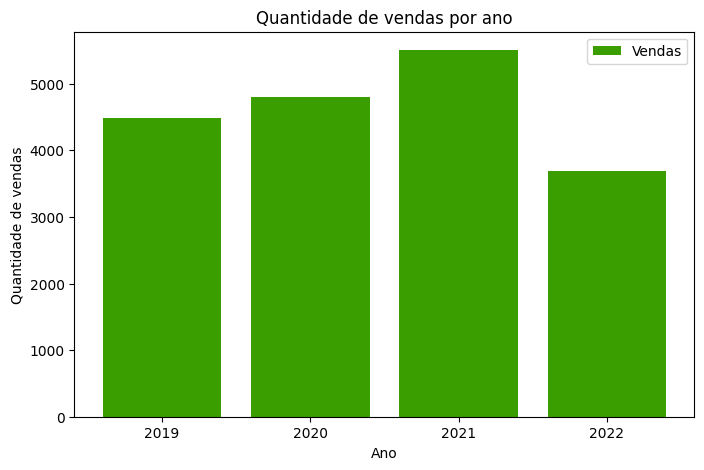

In [177]:
# Agora vamos analisar a quantidade de vendas por ano

vendas_por_ano = (
    vendas_renomeado
    .assign(ano=vendas_renomeado["data_compra"].dt.year)
    .groupby("ano")["nota_fiscal"]
    .nunique()
    .reset_index(name="qtd_vendas")
)

display(vendas_por_ano)

# Gráfico

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    vendas_por_ano["ano"],
    vendas_por_ano["qtd_vendas"],
    color="#3A9E01",
    label="Vendas"
)

ax.set_title("Quantidade de vendas por ano")
ax.set_xlabel("Ano")
ax.set_ylabel("Quantidade de vendas")
ax.set_xticks(vendas_por_ano["ano"])
ax.legend()

plt.show()

Podemos verificar que essa base de dados possui informações de 2019 a 2022.  
2021 foi o ano com mais vendas, em 2022 houve uma queda significativa das vendas, sendo menor que as vendas nos anos anteriores.

In [203]:
# Verificando a média de vendas por ano
media_vendas = np.mean(vendas_por_ano["qtd_vendas"])
print(f"Média de vendas por ano: {media_vendas}")

# Identificando se o número de venda ficou acima ou abaixo da média
vendas_por_ano["comparacao_media"] = np.where(
    vendas_por_ano["qtd_vendas"] >= media_vendas,
    "Acima da média",
    "Abaixo da média"
)
display(vendas_por_ano)

Média de vendas por ano: 4617.75


,ano,qtd_vendas,comparacao_media
0,2019,4483,Abaixo da média
1,2020,4794,Acima da média
2,2021,5505,Acima da média
3,2022,3689,Abaixo da média


,mes,qtd_vendas
9,10,711
0,1,616
6,7,599
8,9,594
5,6,445
1,2,433
11,12,412
7,8,386
2,3,382
3,4,363


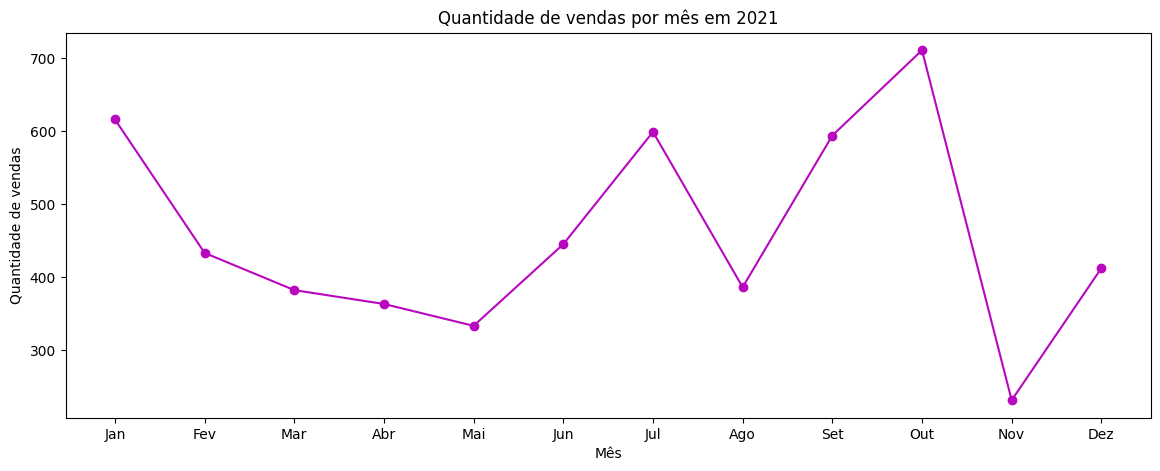

In [178]:
# Vendas por mês no ano de 2021

vendas_por_mes_2021 = (
    vendas_renomeado[vendas_renomeado["data_compra"].dt.year == 2021]
    .groupby(vendas_renomeado["data_compra"].dt.month)["nota_fiscal"]
    .nunique()
    .reset_index(name="qtd_vendas")
)

vendas_por_mes_2021.columns = ["mes", "qtd_vendas"]

display(vendas_por_mes_2021.sort_values(by= "qtd_vendas", ascending=False))

# Gráfico
meses = [
    "Jan", "Fev", "Mar", "Abr", "Mai", "Jun",
    "Jul", "Ago", "Set", "Out", "Nov", "Dez"
]

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    vendas_por_mes_2021["mes"],
    vendas_por_mes_2021["qtd_vendas"],
    color="#B807BE",
    marker="o",
)

ax.set_title("Quantidade de vendas por mês em 2021")
ax.set_xlabel("Mês")
ax.set_ylabel("Quantidade de vendas")

ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses)

plt.show()

Em 2021, o mês com o maior número de vendas foi "Outubro" com 711 vendas.  
E o mês com o menor número de vendas foi "Novembro" com 231 vendas.

,mes,qtd_vendas
0,1,566
6,7,446
1,2,430
4,5,429
2,3,364
3,4,318
11,12,313
5,6,301
7,8,273
10,11,155


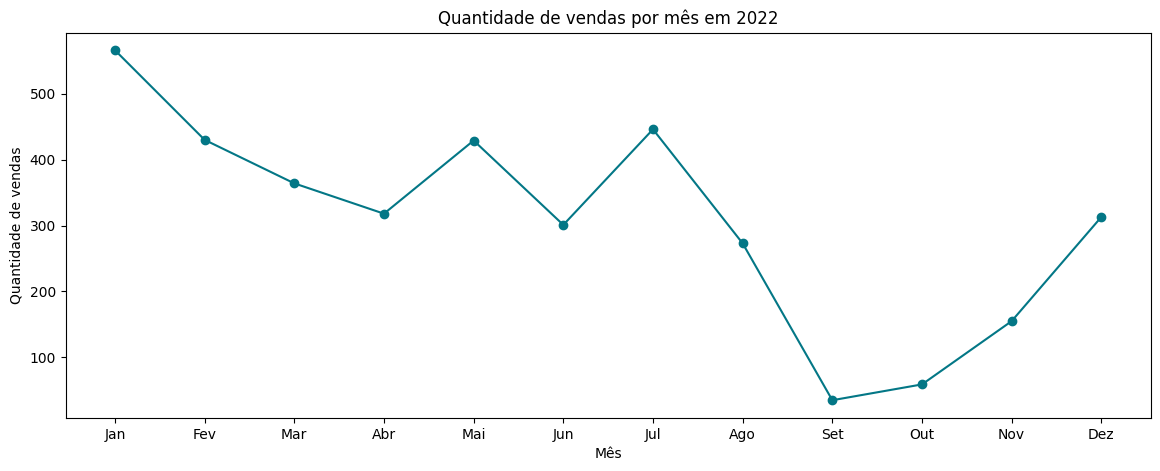

In [179]:
# Vendas por mês no ano de 2022

vendas_por_mes_2022 = (
    vendas_renomeado[vendas_renomeado["data_compra"].dt.year == 2022]
    .groupby(vendas_renomeado["data_compra"].dt.month)["nota_fiscal"]
    .nunique()
    .reset_index(name="qtd_vendas")
)

vendas_por_mes_2022.columns = ["mes", "qtd_vendas"]

display(vendas_por_mes_2022.sort_values(by= "qtd_vendas", ascending=False))

# Gráfico
meses = [
    "Jan", "Fev", "Mar", "Abr", "Mai", "Jun",
    "Jul", "Ago", "Set", "Out", "Nov", "Dez"
]

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    vendas_por_mes_2022["mes"],
    vendas_por_mes_2022["qtd_vendas"],
    color="#037786",
    marker="o",
)

ax.set_title("Quantidade de vendas por mês em 2022")
ax.set_xlabel("Mês")
ax.set_ylabel("Quantidade de vendas")

ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses)

plt.show()

Em 2022, o mês com o maior número de vendas foi "Janeiro" com 566 vendas.  
E o mês com o menor número de vendas foi "Setembro" com 35 vendas.

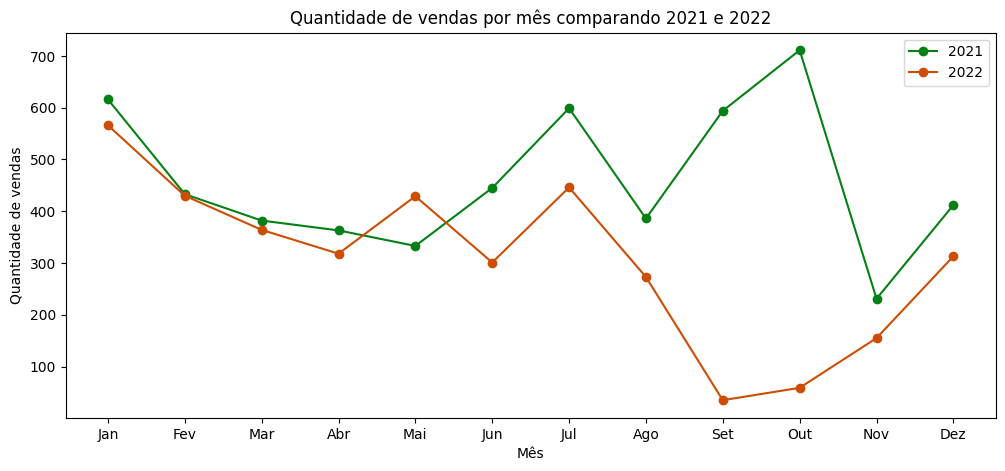

In [180]:
# Comparando a quantidade de vendas dos anos 2021 e 2022

vendas_por_mes = (
    vendas_renomeado
    [vendas_renomeado["data_compra"].dt.year.isin([2021, 2022])]
    .assign(
        ano=lambda x: x["data_compra"].dt.year,
        mes=lambda x: x["data_compra"].dt.month
    )
    .groupby(["ano", "mes"])["nota_fiscal"]
    .nunique()
    .reset_index(name="qtd_vendas")
)


meses = [
    "Jan", "Fev", "Mar", "Abr", "Mai", "Jun",
    "Jul", "Ago", "Set", "Out", "Nov", "Dez"
]



fig, ax = plt.subplots(figsize=(12, 5))

# Filtra 2021
vendas_2021 = vendas_por_mes[vendas_por_mes["ano"] == 2021]

# Filtra 2022
vendas_2022 = vendas_por_mes[vendas_por_mes["ano"] == 2022]

# Linha de 2021
ax.plot(
    vendas_2021["mes"],
    vendas_2021["qtd_vendas"],
    color="#048015",
    marker="o",
    label="2021"
)

# Linha de 2022
ax.plot(
    vendas_2022["mes"],
    vendas_2022["qtd_vendas"],
    color="#CC4D03",
    marker="o",
    label="2022"
)

ax.set_title("Quantidade de vendas por mês comparando 2021 e 2022")
ax.set_xlabel("Mês")
ax.set_ylabel("Quantidade de vendas")

ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses)

ax.legend()
plt.show()

Com o gráfico comparando os anos de 2021 e 2022, é possível verificar que somente em MAIO o número de vendas foi maior em 2022 do que em 2021.

#### 6.2 Produtos mais vendidos × classe econômica

Quais são os produtos mais comprados por cada classe econômica?

,produto,classe_economica,qtd_vendas
255,PRESUNTO COZIDO,A,746
144,GEL,A,505
78,CERA,A,502
183,LIMAO,A,500
291,REFRIGERANTE OUTROS,A,496


,produto,classe_economica,qtd_vendas
256,PRESUNTO COZIDO,B,5876
244,PAPINHA INFANTIL,B,3754
241,PAPEL HIGIENICO,B,3751
325,SARDINHA,B,3743
73,CEBOLA,B,3728


,produto,classe_economica,qtd_vendas
257,PRESUNTO COZIDO,C,2557
326,SARDINHA,C,1678
149,GRANOLA,C,1665
62,BIFE DE COXAO MOLE,C,1661
104,CREME,C,1649


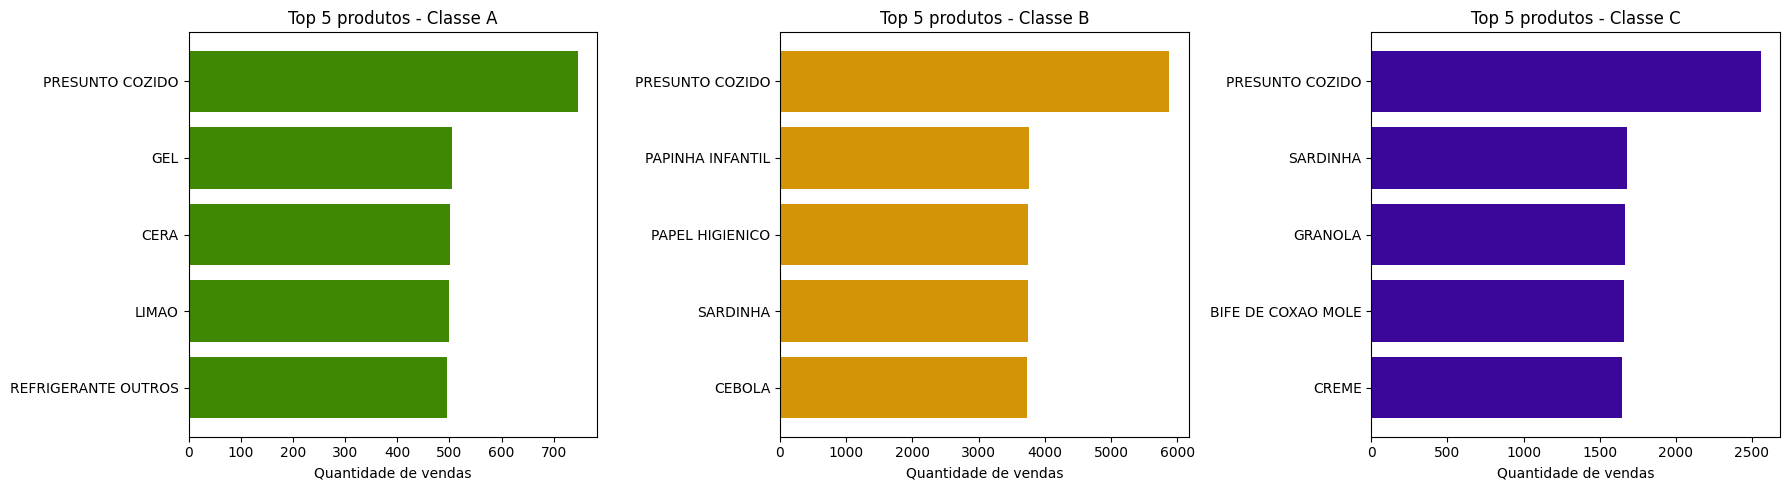

In [181]:
produtos_classe = (
    vendas_renomeado
    .groupby(["produto", "classe_economica"])["nota_fiscal"]
    .nunique()
    .reset_index(name="qtd_vendas")
    .sort_values(by="qtd_vendas", ascending=False)
)
#print(produtos_classe)


# Top 5 produtos mais vendidos por Classe econômica

top_5_A = produtos_classe[
    produtos_classe["classe_economica"] == "A"
].head(5)

top_5_B = produtos_classe[
    produtos_classe["classe_economica"] == "B"
].head(5)

top_5_C = produtos_classe[
    produtos_classe["classe_economica"] == "C"
].head(5)

display(top_5_A)
display(top_5_B)
display(top_5_C)


# Gráficos

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Classe A
top_5_A = top_5_A.sort_values("qtd_vendas", ascending=True)
axs[0].barh(
    top_5_A["produto"],
    top_5_A["qtd_vendas"],
    color="#3F8804"
)
axs[0].set_title("Top 5 produtos - Classe A")
axs[0].set_xlabel("Quantidade de vendas")

# Classe B
top_5_B = top_5_B.sort_values("qtd_vendas", ascending=True)
axs[1].barh(
    top_5_B["produto"],
    top_5_B["qtd_vendas"],
    color="#D49408"
)
axs[1].set_title("Top 5 produtos - Classe B")
axs[1].set_xlabel("Quantidade de vendas")

# Classe C
top_5_C = top_5_C.sort_values("qtd_vendas", ascending=True)
axs[2].barh(
    top_5_C["produto"],
    top_5_C["qtd_vendas"],
    color="#3B079B"
)
axs[2].set_title("Top 5 produtos - Classe C")
axs[2].set_xlabel("Quantidade de vendas")

plt.tight_layout()
plt.show()

Podemos identificar que, em todas as classes econômicas, o produto mais vendido é o "PRESUNTO COZIDO".

#### 6.3 Quantidade de vendas por gênero

Quem compra mais? Homens ou mulheres?

,sexo,qtd_vendas
0,F,9615
1,M,8856


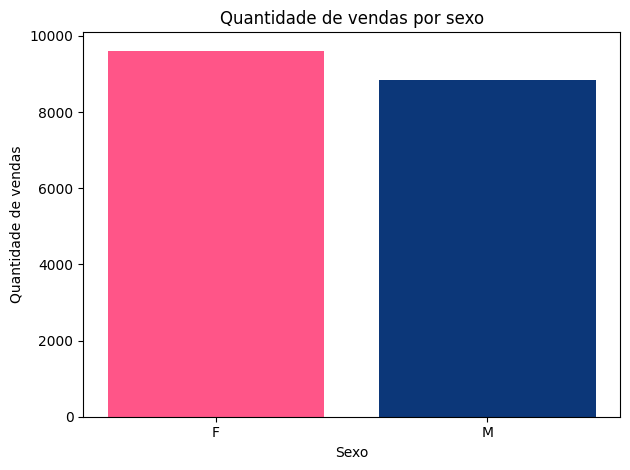

In [200]:
vendas_sexo = (
    vendas_renomeado
    .groupby(["sexo"])["nota_fiscal"]
    .nunique()
    .reset_index(name="qtd_vendas")
    .sort_values("qtd_vendas", ascending=False)
)

display(vendas_sexo)

# Gráfico
fig, ax = plt.subplots()

ax.bar(
    vendas_sexo["sexo"],
    vendas_sexo["qtd_vendas"],
    color=["#FF5588", "#0C3779"]
)

ax.set_title("Quantidade de vendas por sexo")
ax.set_xlabel("Sexo")
ax.set_ylabel("Quantidade de vendas")

plt.tight_layout()
plt.show()

Foi possível identificar que as mulheres compraram mais que os homens.

#### 6.4 Sexo × Classe econômica — quantidade de vendas

Qual combinação de sexo e classe econômica concentra mais vendas?

,sexo,classe_economica,qtd_vendas
1,F,B,5946
4,M,B,5897
2,F,C,2969
5,M,C,2167
3,M,A,792
0,F,A,700


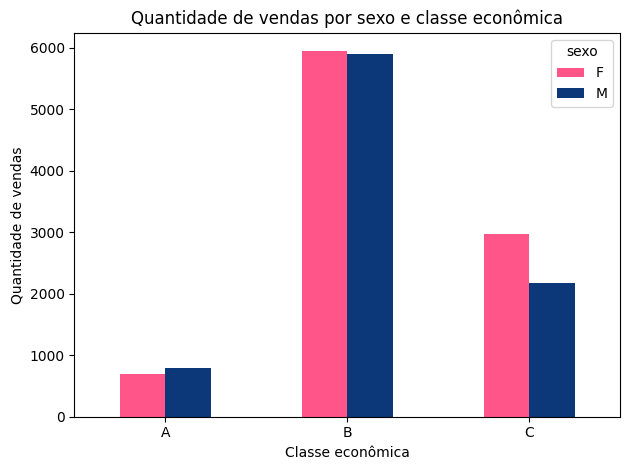

In [183]:
vendas_sexo_classe = (
    vendas_renomeado
    .groupby(["sexo", "classe_economica"])["nota_fiscal"]
    .nunique()
    .reset_index(name="qtd_vendas")
    .sort_values("qtd_vendas", ascending=False)
)

display(vendas_sexo_classe)

# Gráfico
vendas_sexo_classe.pivot(
    index="classe_economica",
    columns="sexo",
    values="qtd_vendas"
).plot(kind="bar", color=["#FF5588", "#0C3779"])

plt.title("Quantidade de vendas por sexo e classe econômica")
plt.xlabel("Classe econômica")
plt.ylabel("Quantidade de vendas")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()




Foi possível analisar que a classe B compra mais que as demais, e que apenas na classe A os homens compraram mais que as mulheres.

#### 6.5 Maior número de vendas por categoria

In [184]:
vendas_categoria = (
    vendas_renomeado
    .groupby("categoria")["nota_fiscal"]
    .nunique()
    .reset_index(name="qtd_vendas")
    .sort_values("qtd_vendas", ascending=False)
)

display(vendas_categoria)

,categoria,qtd_vendas
2,ALIMENTOS,18267
4,HIGIENE,17610
5,LIMPEZA,17475
3,BEBIDAS,14735
6,PET,13495
1,ACESSORIOS,9224
0,#N/D,3228


In [186]:
categoria_mais_vendida = vendas_categoria.iloc[0]

print(
    f"A categoria que teve mais vendas foi "
    f"{categoria_mais_vendida['categoria']}, "
    f"com {categoria_mais_vendida['qtd_vendas']} vendas."
)

A categoria que teve mais vendas foi ALIMENTOS, com 18267 vendas.


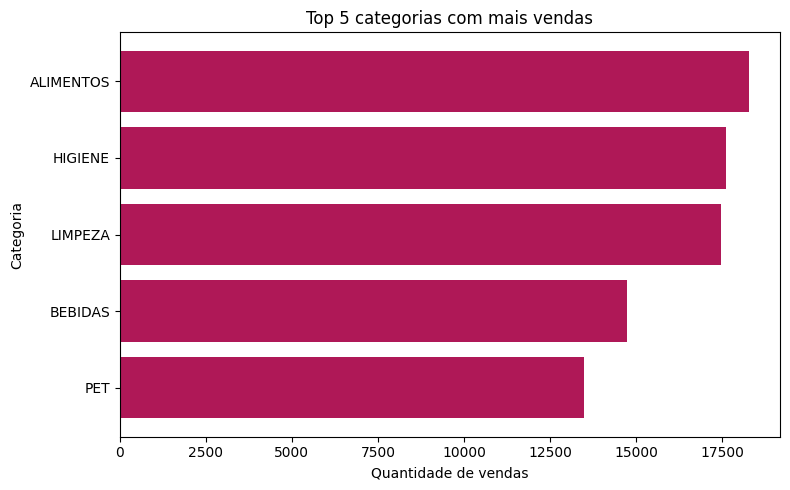

In [197]:
top_5_categorias = (
    vendas_categoria
    .head(5)
    .sort_values("qtd_vendas", ascending=True)
)

# display(top_5_categorias)

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    top_5_categorias["categoria"],
    top_5_categorias["qtd_vendas"],
    color="#AF1857"
)

ax.set_title("Top 5 categorias com mais vendas")
ax.set_xlabel("Quantidade de vendas")
ax.set_ylabel("Categoria")

plt.tight_layout()
plt.show()

### 7. Conclusão

Produzir um pequeno bloco de conclusões (3–6 tópicos) com os principais insights obtidos e possíveis problemas remanescentes na base. Notebook Python, MD ou um “print”.

#### 7.1 Análise

Conclusões que eu consegui identificar ao analisar essa base de dados:


- O produto com código 107 está sem identificação de NOME e CATEGORIA.
- Foram removidas 96553 linhas duplicadas.
- O período de dados dessa base é de 2019 a 2022.
- O ano com o maior número de vendas é 2021.
- O ano com o menor número de vendas é 2022.
- A classe econômica que mais compra é a B.
- O produto mais vendido em todas as classes é o "PRESUNTO COZIDO".
- Considerando os valores gerais, as mulheres compraram mais do que os homens. Porém, ao segmentar por classe, verificamos que na classe A os homens compraram mais que as mulheres.
- A categoria com o maior número de vendas é "ALIMENTOS".